# Generating Samples

Author: Fred J. Hickernell

This notebook generates IID and low discrepancy samples from several distributions and visualizes how the sampling design affects the resulting points and estimates.

Use Jupyter with the `qmcpy` environment described in the [MATH 565 repository](https://github.com/fjhickernell/MATH565Fall2026), or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/GeneratingSamples.ipynb)

In Colab, run the setup cell below once and then continue in order. It installs the course's recorded `classlib` and QMCPy versions plus TeX support, which may take several minutes. Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.

#### LaTeX macros
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vZ}{\boldsymbol{Z}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

### Import packages and initialize the notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import scipy.stats as stats
import qmcpy as qp
from statsmodels.distributions.empirical_distribution import ECDF
import classlib as cl

%matplotlib inline

cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT


## IID binomial samples

We start with the distribution of the number of successful free throws in three attempts for a shooter whose success probability is $0.6$.

- Generate $n$ samples with `scipy.stats.binom.rvs`
- Compare empirical PMFs for $n=10$ and $n=1000$
- Overlay the true PMF

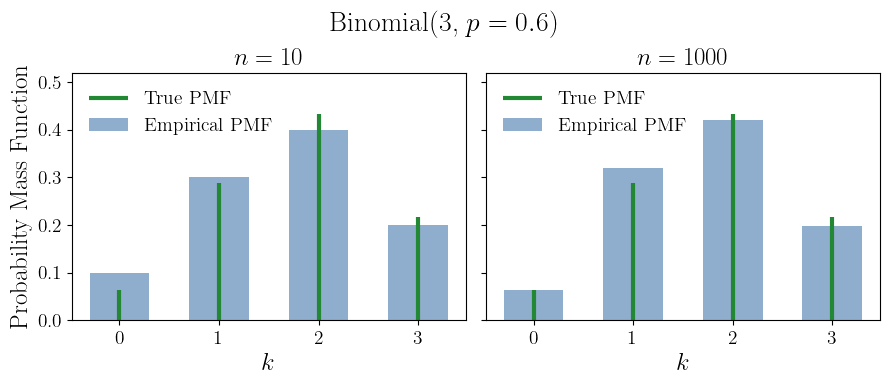

In [3]:
num_trials, p = 3, 0.6  #the parameters of the Binomial distribution
free_throws_rv = stats.binom(n=num_trials, p=p)  #set up a Binomial random variable
k = np.arange(num_trials+1)  #possible numbers of successes
pmf = free_throws_rv.pmf(k)  #evaluate the true (population) values of the probability mass function

n_vals = np.array([10, 1000])  #different sample sizes
num_sizes = len(n_vals)
bins=np.arange(-0.25, num_trials+1.25, 0.5)
fig, axes = plt.subplots(1, num_sizes, figsize=(4.5*num_sizes, 4), sharey=True)

ymax = 1.2*pmf.max()
for ax, n in zip(axes, n_vals):
    samples = free_throws_rv.rvs(size=n)
    freq = np.bincount(samples, minlength=num_trials+1) / n   # empirical PMF
    ax.bar(k, freq, width=0.6, color=colors["blue"], alpha=0.6, label="Empirical PMF")
    ax.vlines(k, 0, pmf, colors=colors["green"], lw=3, label="True PMF")
    ax.set_title(f"$n={n}$")
    ax.set_xlabel("$k$")
    ymax = max(ymax, 1.1 * freq.max())
    ax.legend(loc="upper left")

axes[0].set_ylim(0, ymax)
axes[0].set_ylabel("Probability Mass Function")
fig.suptitle(f"Binomial({num_trials}, $p={p}$)", y=0.95, fontsize = 20)
plt.tight_layout()

<div class="highlight-note">
Note:
<ul>
  <li>Every run produces different IID samples</li>
  <li>Larger samples tend to give more accurate empirical approximations to the true PMF</li>
</ul></div>

Next we plot the CDF and quantile function.

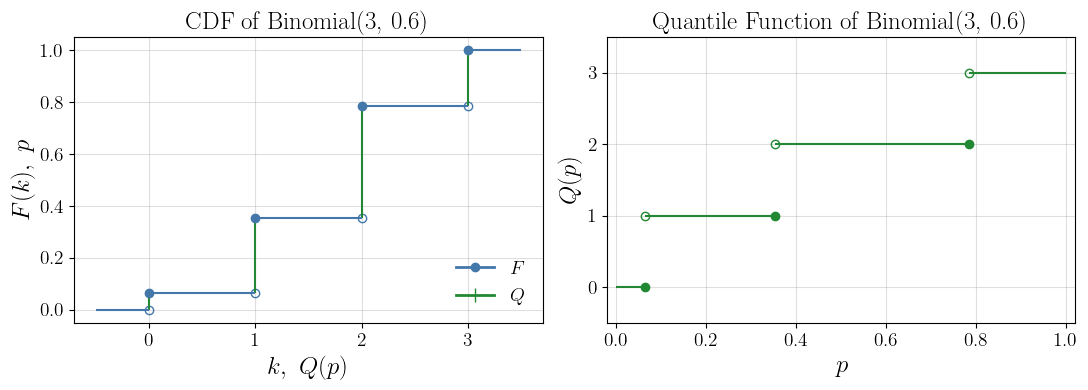

In [4]:
# probabilities for quantile function
cdf_vals = free_throws_rv.cdf(k)  #values of the cdf on the sample space

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# --- Left: CDF ---
for i in range(num_trials+2):
    if i == 0:
        x_start, y_val = -0.5, 0
    else:
        x_start, y_val = k[i-1], cdf_vals[i-1]
        axes[0].plot(x_start, y_val, "o", color=colors["blue"]) #closed circle at left
    if i < num_trials + 1:
        x_end = k[i]
        axes[0].plot(x_end, y_val, "o", color=colors["blue"], fillstyle="none")  #open circle at right
        axes[0].vlines(x_end, y_val, cdf_vals[i], color=colors["green"])  #horizontal line for piecwise constant quantile function
    else:
        x_end = num_trials + 0.5
    axes[0].hlines(y_val, x_start, x_end, color=colors["blue"])  #horizontal line for piecwise constant cdf
axes[0].set_title("CDF of Binomial(3, 0.6)")
axes[0].set_xlabel(r"$k,\ Q(p)$")
axes[0].set_ylabel(r"$F(k),\ p$")
axes[0].set_xticks(k)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.4)
cdf_handle = mlines.Line2D([], [], color=colors["blue"], marker="o", markersize=6, lw=2, label=r"$F$")
q_handle   = mlines.Line2D([], [], color=colors["green"], marker="|", markersize=10, lw=2, label=r"$Q$")
axes[0].legend(handles=[cdf_handle, q_handle], loc="lower right", frameon=False)

# --- Right: Quantile Function ---
for i, ki in enumerate(k):
    y_val = ki
    if i == 0:
        p_start = 0.0
    else:
        p_start = cdf_vals[i-1]
        axes[1].plot(p_start, y_val, "o", color=colors["green"], fillstyle="none")  # open circle at left
    if i < num_trials:
        p_end = cdf_vals[i]
        axes[1].plot(p_end, y_val, "o", color=colors["green"])  # closed circle at right
    else:
        p_end = 1.0
    axes[1].hlines(y_val, p_start, p_end, color=colors["green"])  # horizontal line for piecewise constant quantile

axes[1].set_title("Quantile Function of Binomial(3, 0.6)")
axes[1].set_xlabel("$p$")
axes[1].set_ylabel("$Q(p)$")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.5, num_trials+0.5)
axes[1].grid(alpha=0.4)
plt.tight_layout()

- The CDF is **right-continuous** and is defined on $\mathbb{R}$
- The quantile function is **left-continuous** on $(0,1)$

## Zero-inflated exponential distribution

There is a positive probability of zero waiting time; conditional on a positive wait, the distribution is exponential.

- Probability of zero wait: $p_0=0.2$
- Positive waits: exponential with mean $10$ minutes
- Compare empirical CDFs for $n=10$ and $n=1000$ with the true CDF

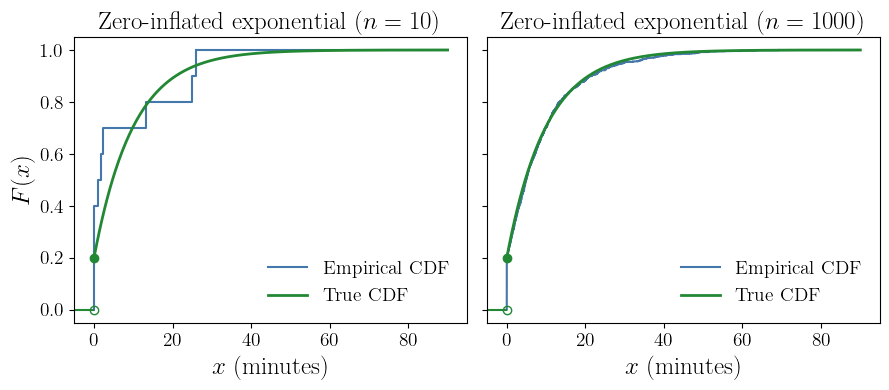

In [5]:
# Parameters
p_zero = 0.2
mean_pos = 10.0
n_vals = [10, 1000]
xmax = 90

# QMCPy performs the uniform-to-target transformation. The classlib SciPy
# distribution supplies the analytic CDF used as a benchmark in the plots.
zie_iid = qp.ZeroInflatedExpUniform(
    qp.IIDStdUniform(1), p_zero=p_zero, lam=1 / mean_pos
)
zie_cdf = cl.distributions.make_zie(p_zero=p_zero, mean_pos=mean_pos)

fig, axes = plt.subplots(1, len(n_vals), figsize=(9, 4), sharey=True)
for ax, n in zip(axes, n_vals):
    samples = zie_iid(n).ravel()
    ecdf = ECDF(samples)
    ax.step(ecdf.x, ecdf.y, where="post", label="Empirical CDF", color=colors["blue"])
    ax.hlines(ecdf.y[-1], ecdf.x[-1], xmax, colors=colors["blue"])

    ax.hlines(0, -5, 0, colors=colors["green"])
    ax.plot(0, 0, "o", color=colors["green"], fillstyle="none")
    ax.plot(0, p_zero, "o", color=colors["green"])
    grid = np.linspace(0, xmax, 400)
    ax.plot(grid, zie_cdf.cdf(grid), color=colors["green"], lw=2, label="True CDF")
    ax.set_xlim(-5, xmax + 5)
    ax.set_title(f"Zero-inflated exponential ($n={n}$)")
    ax.set_xlabel("$x$ (minutes)")
    ax.legend(loc="lower right")

axes[0].set_ylabel("$F(x)$")
plt.tight_layout()

<div class="highlight-note">
Note:
<ul>
  <li>Larger samples tend to approximate the CDF more closely</li>
  <li>$F$ is discontinuous at $x=0$</li>
</ul></div>

## Gaussian-mixture samples

Choose component $C=1$ with probability $p=0.3$ and $C=2$ otherwise, then draw from that component's normal distribution. For independent $U_1,U_2\sim\operatorname{Unif}(0,1)$,

\begin{align*}
C &= \begin{cases}1,&U_1\le p,\\2,&U_1>p,\end{cases}
& X &= \mu_C+\sigma_C\Phi^{-1}(U_2),\\
(\mu_1,\sigma_1)&=(-2,0.5),
& (\mu_2,\sigma_2)&=(1,1).
\end{align*}

Here $\Phi$ and $\phi$ are the standard normal CDF and PDF. This construction avoids inverting the mixture CDF. Compare the sample histogram with the analytic density

\begin{align*}
\varrho_X(x)=\frac{p}{\sigma_1}\phi\left(\frac{x-\mu_1}{\sigma_1}\right)
+\frac{1-p}{\sigma_2}\phi\left(\frac{x-\mu_2}{\sigma_2}\right).
\end{align*}


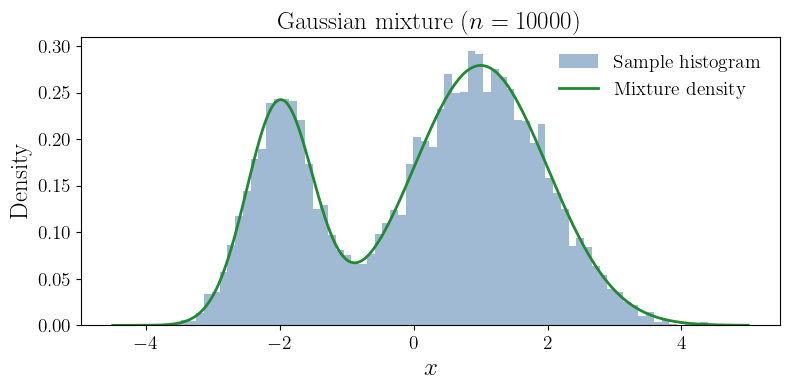

In [6]:
mixture_p = 0.3
mixture_mu = np.array([-2.0, 1.0])
mixture_sigma = np.array([0.5, 1.0])
mixture_n = 10000

# Independent uniform coordinates select the component and its normal quantile.
mixture_U = qp.IIDStdUniform(2)(mixture_n)
component = np.where(mixture_U[:, 0] <= mixture_p, 0, 1)  # zero-based indices
mixture_samples = (
    mixture_mu[component]
    + mixture_sigma[component] * stats.norm.ppf(mixture_U[:, 1])
)
mixture_grid = np.linspace(-4.5, 5.0, 600)
mixture_density = (
    mixture_p * stats.norm.pdf(mixture_grid, loc=mixture_mu[0], scale=mixture_sigma[0])
    + (1 - mixture_p)
    * stats.norm.pdf(mixture_grid, loc=mixture_mu[1], scale=mixture_sigma[1])
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mixture_samples, bins=70, density=True, color=colors["blue"],
        alpha=0.5, label="Sample histogram")
ax.plot(mixture_grid, mixture_density, color=colors["green"], lw=2,
        label="Mixture density")
ax.set_xlabel("$x$")
ax.set_ylabel("Density")
ax.set_title(f"Gaussian mixture ($n={mixture_n}$)")
ax.legend()
plt.tight_layout()


## Multivariate Gaussian random variables

Suppose $\vX\sim\operatorname{Norm}(\boldsymbol{\mu},\mathsf{\Sigma})$. Find $\mathsf A$ satisfying

$$
\mathsf{\Sigma}=\mathsf A\mathsf A^\mathsf T,
$$

generate $\vZ_i\overset{\mathrm{IID}}{\sim}\operatorname{Norm}(\vzero,\mathsf I)$, and set

$$
\vX_i=\boldsymbol{\mu}+\mathsf A\vZ_i.
$$

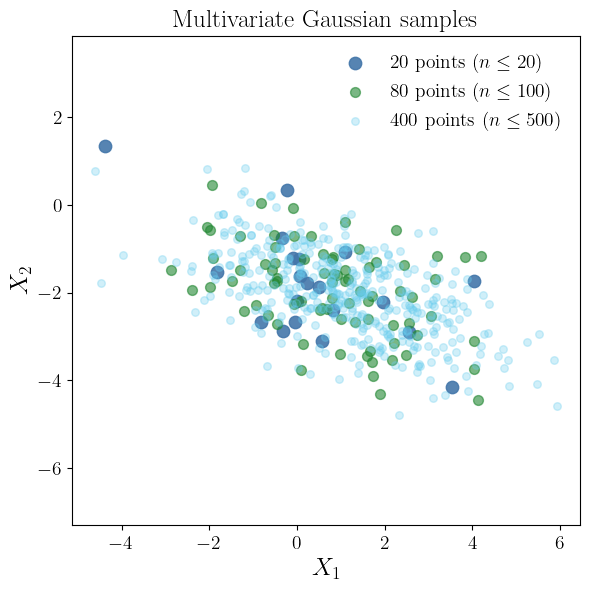

In [7]:
mu = np.array([1.0, -2.0])
Sigma = np.array([[3.0, -1.0],
                  [-1.0, 1.0]])

# QMCPy transforms IID standard uniforms into the target Gaussian distribution.
mvn = qp.Gaussian(
    qp.IIDStdUniform(2), mean=mu, covariance=Sigma, decomp_type="PCA"
)
n_vals = [20, 100, 500]
mvn_samples = mvn(max(n_vals))

colors_list = [colors["blue"], colors["green"], colors["cyan"]]
alpha_list = [0.9, 0.6, 0.3]
size_list = [80, 50, 30]

fig, ax = plt.subplots(figsize=(6, 6))
prev_n = 0
for i, n in enumerate(n_vals):
    ax.scatter(
        mvn_samples[prev_n:n, 0], mvn_samples[prev_n:n, 1],
        s=size_list[i], alpha=alpha_list[i], color=colors_list[i],
        label=f"{n - prev_n} points ($n \le {n}$)",
    )
    prev_n = n
ax.set_title("Multivariate Gaussian samples")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.axis("equal")
ax.legend(loc="upper right")
plt.tight_layout()

The decomposition of $\mathsf{\Sigma} = \mathsf{A} \mathsf{A}^T$ can be performed by the Cholesky decomposition or by eigenvectors and eigenvalues.

In [8]:
mvn_chol = qp.Gaussian(
    qp.IIDStdUniform(2), mean=mu, covariance=Sigma, decomp_type="Cholesky"
)

print("A by Cholesky =\n", mvn_chol.a)
print("\nA A^T =\n", mvn_chol.a @ mvn_chol.a.T)
print("\nA by principal components =\n", mvn.a)
print("\nA A^T =\n", mvn.a @ mvn.a.T)

A by Cholesky =
 [[ 1.73205081  0.        ]
 [-0.57735027  0.81649658]]

A A^T =
 [[ 3. -1.]
 [-1.  1.]]

A by principal components =
 [[ 1.70710678  0.29289322]
 [-0.70710678  0.70710678]]

A A^T =
 [[ 3. -1.]
 [-1.  1.]]


### Gaussian processes and Brownian motion
Gaussian processes are random functions whose values at a finite number of points have a multivariate normal/Gaussian distribution.  They are often denoted $\cgp(\mu, K)$, where for any $g \sim \cgp(\mu, K)$
- $\mu$ is a function on the domain, $\Omega$ of these random functions, i.e., $\Ex[g(\vt)] = \mu(t)$ for all $\vt \in \Omega$, and
- $K$ is the covariance kernel defined on $\Omega \times \Omega$, i.e., $\Ex[\{g(\vt)-\mu(\vt)\}\{g(\vx)-\mu(\vx)\}] = K(\vt,\vx)$ for all $\vt, \vx \in \Omega$

Brownian motions, often denoted by $B$, (also called Wiener processes, denoted by $W$)  are an important special case of Gaussian processes:
$$
\Omega = [0, T], \qquad \mu(t) = 0, \qquad K(t,x) = \min(t,x)
$$
So if $0 \le t_1 \le t_2 \le \cdots \le t_d$ are specific times of interest, the multivariate normal random variable $\vX = (B(t_1), \ldots, B(t_d))$ has distribution $\operatorname{Norm}(\vzero, \mathsf{\Sigma})$, where 
$$
\Sigma = \begin{pmatrix}
t_1 & t_1 & t_1 & \cdots & t_1 \\
t_1 & t_2 & t_2 & \cdots & t_2 \\
t_1 & t_2 & t_3 & \cdots & t_3 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
t_1 & t_2 & t_3 & \cdots & t_d
\end{pmatrix} 
= \underbrace{
\begin{pmatrix}
\sqrt{t_1} & 0 & 0 & \cdots & 0 \\
\sqrt{t_1} & \sqrt{t_2 - t_1} & 0 & \cdots & 0 \\
\sqrt{t_1} & \sqrt{t_2 - t_1} & \sqrt{t_3-t_2} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\sqrt{t_1} & \sqrt{t_2 - t_1} & \sqrt{t_3-t_2} & \cdots & \sqrt{t_d - t_{d-1}}
\end{pmatrix}}_{\large\mathsf{A}}
\underbrace{\begin{pmatrix}
\sqrt{t_1} & \sqrt{t_1} & \sqrt{t_1} & \cdots & \sqrt{t_1} \\
0 & \sqrt{t_2 - t_1} &\sqrt{t_2 - t_1} & \cdots & \sqrt{t_2 - t_1} \\
0 & 0 & \sqrt{t_3-t_2} & \cdots & \sqrt{t_3-t_2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \sqrt{t_d - t_{d-1}}
\end{pmatrix}}_{\large\mathsf{A}^\top}
$$
Below we plot some Brownian paths

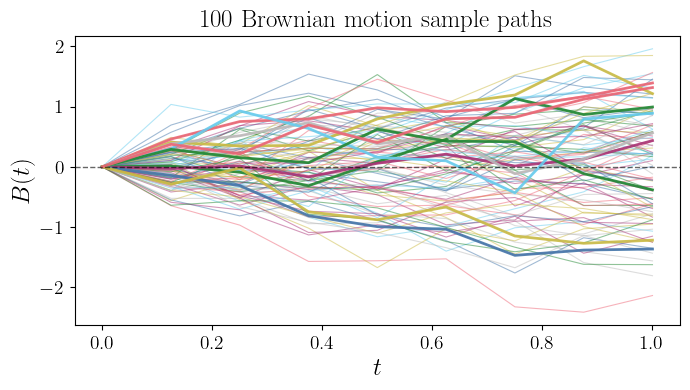

In [9]:
n_paths = 100
n_steps = 8
bm = qp.BrownianMotion(
    qp.IIDStdUniform(n_steps), t_final=1, decomp_type="PCA"
)
BM_paths = np.column_stack([np.zeros(n_paths), bm(n_paths)])
t_vec = np.concatenate([[0.0], bm.time_vec])

plt.figure(figsize=(7, 4))
plt.plot(t_vec, BM_paths.T, lw=0.8, alpha=0.5)
plt.plot(t_vec, BM_paths[:10].T, lw=2, alpha=0.9)
plt.axhline(0, lw=1, ls="--", c="k", alpha=0.6)
plt.xlabel(r"$t$")
plt.ylabel(r"$B(t)$")
plt.title(f"{n_paths} Brownian motion sample paths")
plt.tight_layout()

### Modeling stock prices
Brownian motions are used in financial modeling.  If 
- $S_0$ is the initial price of a stock/asset
- $r$ is the interest rate
- $\sigma$ is the volatility
Then
$$
S(t) = S_0 \exp\bigl((r -\sigma^2/2)t  + \sigma B(t) \bigr)
$$
is a _geometric Brownian motion_ model of the stock price

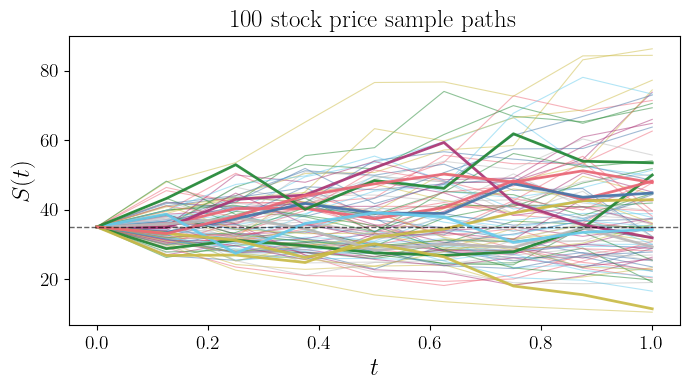

In [10]:
r = 0.1
sigma = 0.4
S_0 = 35
gbm = qp.GeometricBrownianMotion(
    qp.IIDStdUniform(n_steps),
    t_final=1,
    initial_value=S_0,
    drift=r,
    diffusion=sigma**2,
    decomp_type="PCA",
)
S_paths = np.column_stack([np.full(n_paths, S_0), gbm(n_paths)])

plt.figure(figsize=(7, 4))
plt.plot(t_vec, S_paths.T, lw=0.8, alpha=0.5)
plt.plot(t_vec, S_paths[:10].T, lw=2, alpha=0.9)
plt.axhline(S_0, lw=1, ls="--", c="k", alpha=0.6)
plt.xlabel(r"$t$")
plt.ylabel(r"$S(t)$")
plt.title(f"{n_paths} stock price sample paths")
plt.tight_layout()

As a sanity check, compare the sample mean path with the known expectation $\Ex[S(t)] = S_0 \exp(rt)$

Absolute difference between true mean and sample mean =  [0.         0.31347035 0.67451185 0.0964126  0.08579956 0.43693572
 0.45892675 1.46084349 1.35898839]
RMSE of sample mean =  [0.         0.47499005 0.67122496 0.85185073 1.04512048 1.18407507
 1.34550814 1.44562692 1.62132803]


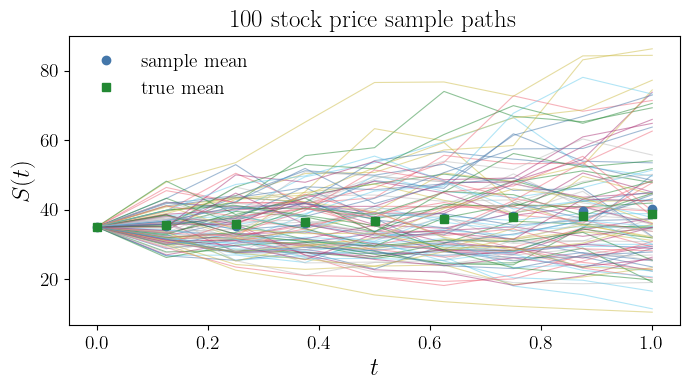

In [11]:
sample_mean_S = np.mean(S_paths, axis = 0)
true_mean_S = S_0*np.exp(r*t_vec)
err_mean_S = true_mean_S - sample_mean_S
plt.figure(figsize=(7, 4))
plt.plot(t_vec, S_paths.T, lw=0.8, alpha=0.5)
plt.plot(t_vec, sample_mean_S, 'o', color = colors["blue"], label='sample mean')
plt.plot(t_vec, true_mean_S, 's', color = colors["green"], label='true mean')
plt.xlabel(r"$t$")
plt.ylabel(r"$S(t)$")
plt.title(fr"{n_paths} stock price sample paths")
plt.legend()
plt.tight_layout()

print("Absolute difference between true mean and sample mean = ",np.abs(err_mean_S))
print("RMSE of sample mean = ", np.std(S_paths, axis = 0)/np.sqrt(n_paths))

### Option pricing

#### Asian arithmetic mean call

The discounted payoff of an arithmetic-mean Asian call option is

$$
\max\left\{\frac1T\int_0^T S(t)\dif t-K,0\right\}\exp(-rT).
$$

QMCPy's `FinancialOption` composes uniform sampling, geometric Brownian motion, trapezoidal averaging, the call payoff, and discounting.

In [12]:
n_steps = 16
option_params = {
    "option": "ASIAN",
    "call_put": "CALL",
    "volatility": 0.5,
    "start_price": 100.0,
    "strike_price": 100.0,
    "interest_rate": 0.02,
    "t_final": 1 / 4,
    "decomp_type": "PCA",
    "asian_mean": "ARITHMETIC",
    "asian_mean_quadrature_rule": "TRAPEZOIDAL",
}
asian_option = qp.FinancialOption(qp.IIDStdUniform(n_steps), **option_params)
asian_option

FinancialOption (AbstractIntegrand)
    option          ASIAN
    call_put        CALL
    volatility      2^(-1)
    start_price     100
    strike_price    100
    interest_rate   0.020
    t_final         2^(-2)
    asian_mean      ARITHMETIC

Repeated simulations reveal the sampling variability of the running sample mean. The shaded band below contains the middle half of the replicated estimates.

Finally we run this simulator for our Asian Arithmetic Mean example.

<div class="highlight-note">
For now, the best way we have to estimate the uncertainty in our sample mean is to do <strong>replications</strong>.
</div>

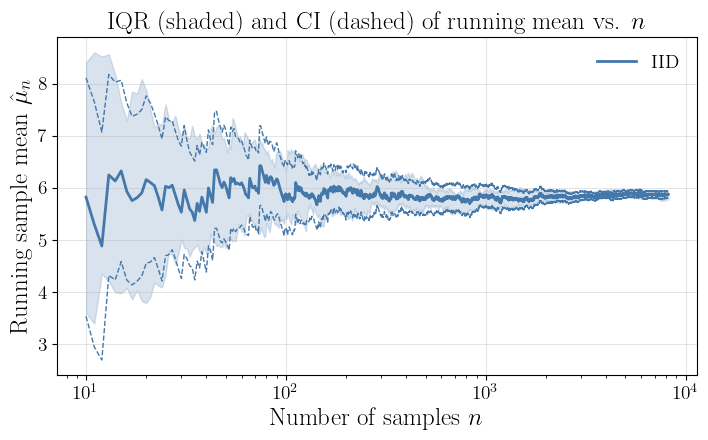

In [13]:
cl.plots.plot_middle_half_sample_mean(
    sampler=lambda n: np.random.random((n, n_steps)),
    f=asian_option.f,
    color=colors["blue"],
    label="IID",
    n_max=2**13,
    n_rep=21,
);

#### Lookback call

A discretely monitored floating-strike lookback call uses the minimum price along the path,

$$
m_d=\min_{0\le j\le d} S_j,
$$

and has discounted payoff

$$
(S_d-m_d)\exp(-rT).
$$

Unlike the Asian call, this floating-strike payoff has no fixed strike price $K$. The path minimum acts as the strike. We keep the same market and monitoring parameters so that the change in payoff is the only change in the model.

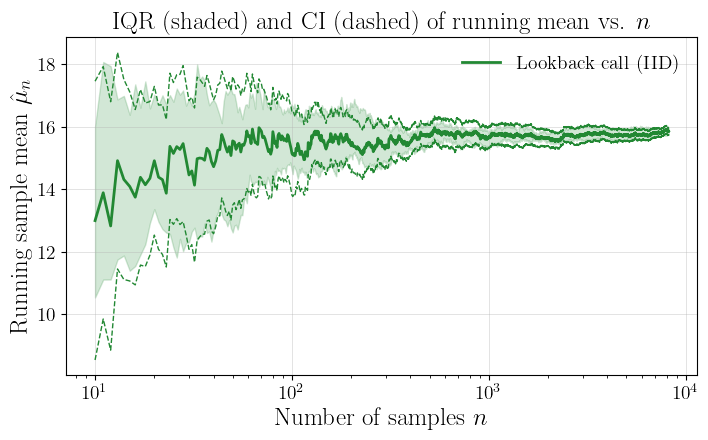

In [14]:
lookback_option = qp.FinancialOption(
    qp.IIDStdUniform(n_steps),
    option="LOOKBACK",
    call_put="CALL",
    volatility=option_params["volatility"],
    start_price=option_params["start_price"],
    interest_rate=option_params["interest_rate"],
    t_final=option_params["t_final"],
    decomp_type=option_params["decomp_type"],
)

cl.plots.plot_middle_half_sample_mean(
    sampler=lambda n: np.random.random((n, n_steps)),
    f=lookback_option.f,
    color=colors["green"],
    label="Lookback call (IID)",
    n_max=2**13,
    n_rep=21,
);

## Low discrepancy sampling

Low discrepancy designs fill the unit cube more evenly than IID samples. The vectors $\vU_0,\vU_1,\ldots$ are not IID. We compare several designs supplied by QMCPy.

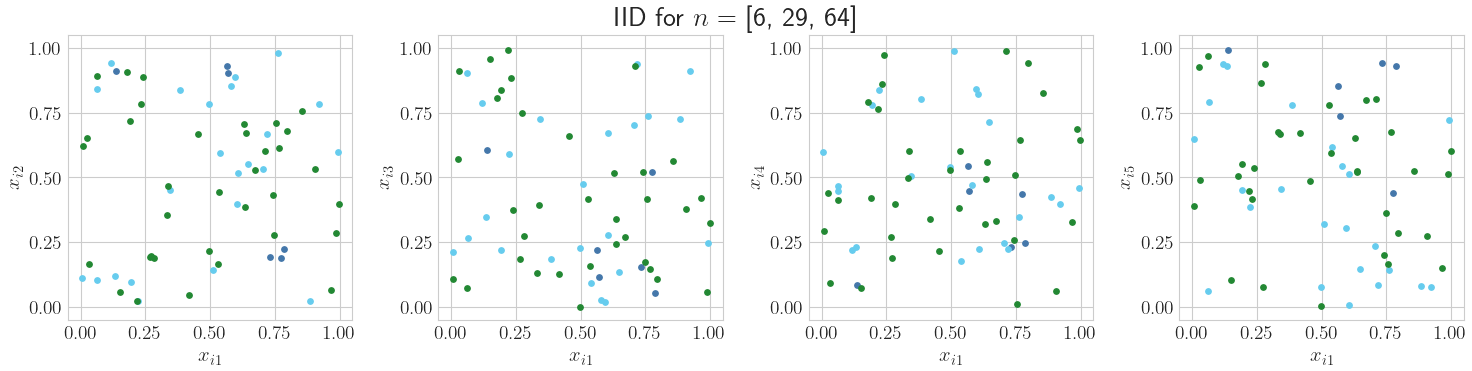

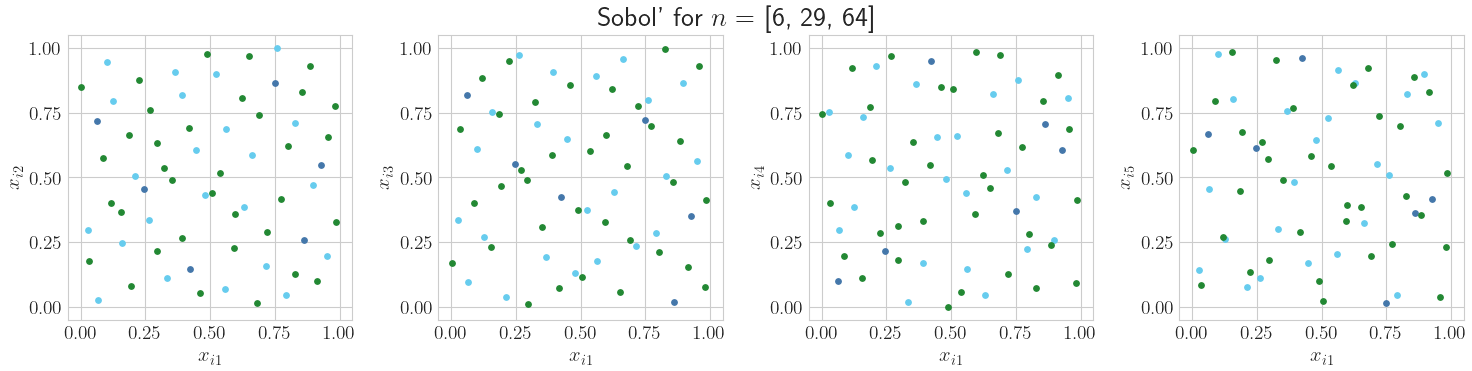

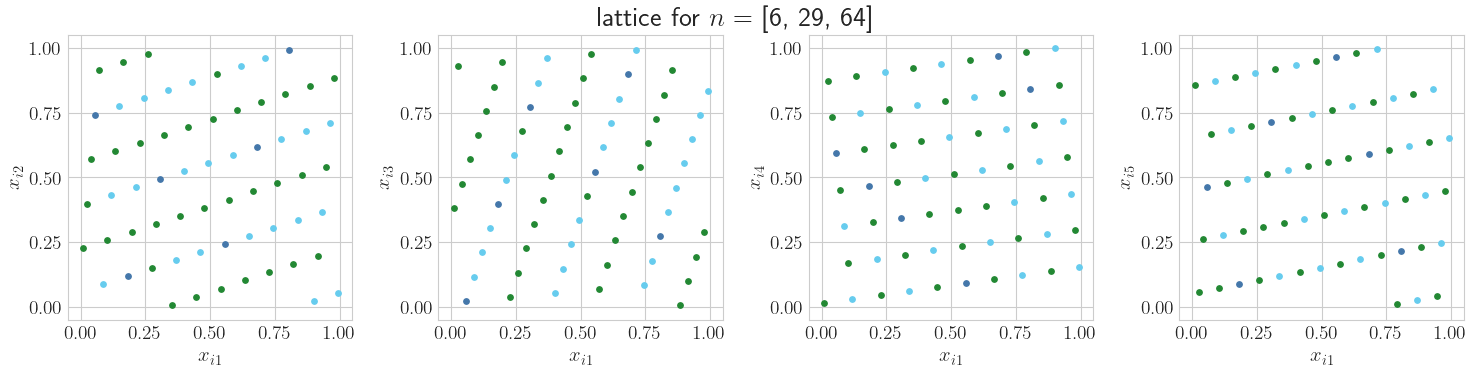

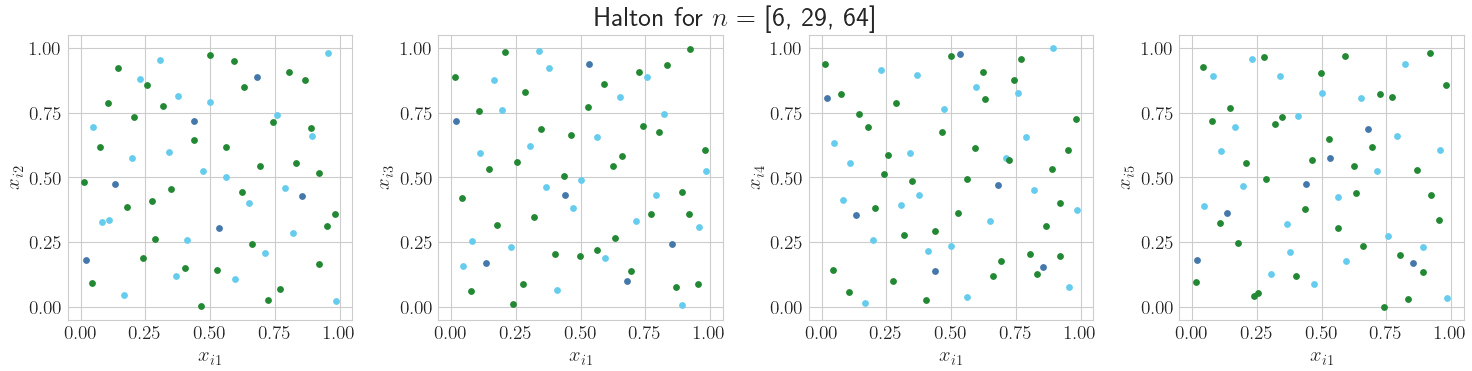

In [15]:
#----Some parameters-----#
d = 6  #the dimension used for these examples
n_list = [6, 29, 64]
ld_params = dict(
    n=n_list, #different values of the sample size
    d_horizontal=np.array([1]),  #coordinates for the rows
    d_vertical=np.arange(2,6),  #coordinates for the columns
    marker_size = 15,  #marker size
    figfac = 15,  #aspect ratio of matrix of figures
    where_title = 0.525,  #make the sup_title in the right place
    axis_pad = 0.05  #border around the figures
)
fig,ax = qp.plot_proj(qp.IIDStdUniform(d), fig_title=f'IID for $n =$ {n_list}', **ld_params)
fig,ax = qp.plot_proj(qp.Sobol(d), fig_title=f"Sobol' for $n =$ {n_list}", **ld_params)
fig,ax = qp.plot_proj(qp.Lattice(d), fig_title=f'lattice for $n =$ {n_list}', **ld_params)
fig,ax = qp.plot_proj(qp.Halton(d), fig_title=f'Halton for $n =$ {n_list}', **ld_params)

<div class="highlight-note">
Note:
<ul>
  <li>The low discrepancy designs fill space more evenly</li>
  <li>Powers of two are natural sample sizes for Sobol' and lattice sequences</li>
</ul></div>

### Binomial distribution with LD sampling

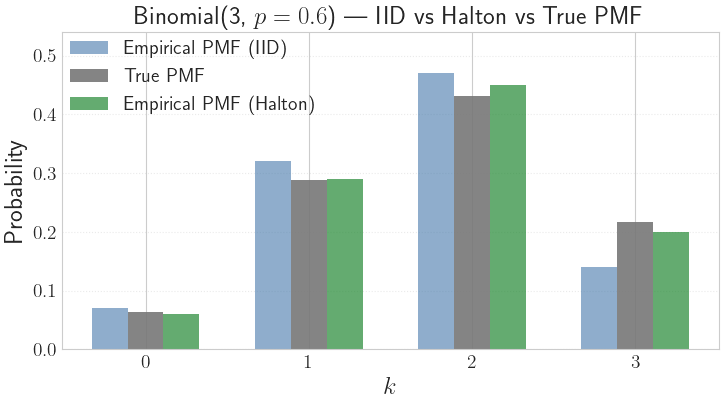

In [16]:
n = 100  #sample size
Halton_uniform_samples = qp.Halton(1, warn=False).gen_samples(n, warn=False).ravel()
Halton_binomial_samples = free_throws_rv.ppf(Halton_uniform_samples).astype(int) 
Halton_freq = np.bincount(Halton_binomial_samples, minlength=num_trials+1) / n # empirical PMF
IID_samples = free_throws_rv.rvs(size=n)
IID_freq = np.bincount(IID_samples, minlength=num_trials+1) / n # empirical PMF

# bar layout params
w = 0.22  # bar width
x = k.astype(float)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(x - w, IID_freq, width=w, color=colors["blue"], alpha=0.6, label="Empirical PMF (IID)") # IID (left)
ax.bar(x, pmf, width=w, color="#777777", alpha=0.9, label="True PMF") # True PMF
ax.bar(x + w, Halton_freq, width=w, color=colors["green"], alpha=0.7, label="Empirical PMF (Halton)")  # Halton (right)
ax.set_xticks(k)
ax.set_xlabel("$k$")
ax.set_ylabel("Probability")
ax.set_title(f"Binomial({num_trials}, $p={p:.2g}$) — IID vs Halton vs True PMF")
ax.set_ylim(0, 1.15*max(pmf.max(), Halton_freq.max(), IID_freq.max()))
ax.legend(loc="best")
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()


### Zero-Inflated Exponential with LD sampling

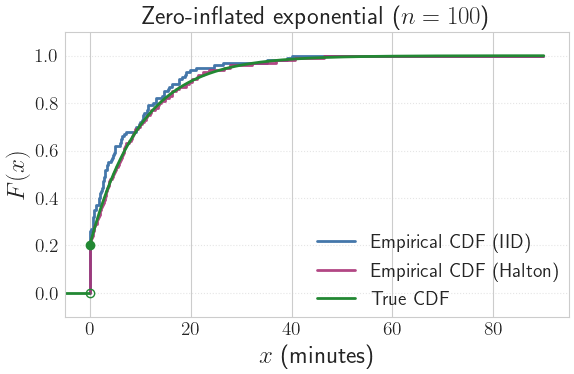

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

samples_iid = qp.ZeroInflatedExpUniform(
    qp.IIDStdUniform(1), p_zero=p_zero, lam=1 / mean_pos
)(n).ravel()
ecdf_iid = ECDF(samples_iid)
ax.step(ecdf_iid.x, ecdf_iid.y, where="post",
        label="Empirical CDF (IID)", color=colors["blue"])
ax.hlines(ecdf_iid.y[-1], ecdf_iid.x[-1], xmax, colors=colors["blue"])

samples_halton = qp.ZeroInflatedExpUniform(
    qp.Halton(1, warn=False), p_zero=p_zero, lam=1 / mean_pos
)(n, warn=False).ravel()
ecdf_halton = ECDF(samples_halton)
ax.step(ecdf_halton.x, ecdf_halton.y, where="post",
        label="Empirical CDF (Halton)", color=colors["purple"], alpha=0.9)
ax.hlines(ecdf_halton.y[-1], ecdf_halton.x[-1], xmax,
          colors=colors["purple"], alpha=0.9)

ax.hlines(0, -5, 0, colors=colors["green"])
ax.plot(0, 0, "o", color=colors["green"], fillstyle="none")
ax.plot(0, p_zero, "o", color=colors["green"])
grid = np.linspace(0, xmax, 400)
ax.plot(grid, zie_cdf.cdf(grid), color=colors["green"], lw=2, label="True CDF")
ax.set_xlim(-5, xmax + 5)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel("$x$ (minutes)")
ax.set_ylabel("$F(x)$")
ax.set_title(f"Zero-inflated exponential ($n={n}$)")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()

### Gaussian mixture with low discrepancy sampling

Apply the same component-selection and normal-quantile map to IID uniform pairs and randomized Sobol' pairs. Sobol' points balance both the component choices and the within-component quantiles; the resulting mixture samples are dependent.

The left plot shows the signed CDF error $\widehat F_n(x)-F_X(x)$ for one realization of each method. The right compares 32 independent randomizations at each sample size using the exact maximum CDF error

\begin{align*}
D_n=\sup_x\left|\widehat F_n(x)-F_X(x)\right|.
\end{align*}

For this continuous target, evaluate both sides of every empirical-CDF jump to compute $D_n$. Smaller values mean a closer distributional match. Lines show the median error and bands the middle half of errors across repetitions. This comparison measures distributional accuracy, not the error of every possible function of the sample.

Dashed lines fit $D_n \approx an^b$ to each method's median errors by least squares on the log--log scale. The fitted exponent $b$ describes this experiment over the displayed sample sizes; it is not a theoretical convergence guarantee.


IID: fitted median CDF error = 0.776 n^(-0.497)
Sobol': fitted median CDF error = 1.1 n^(-0.850)


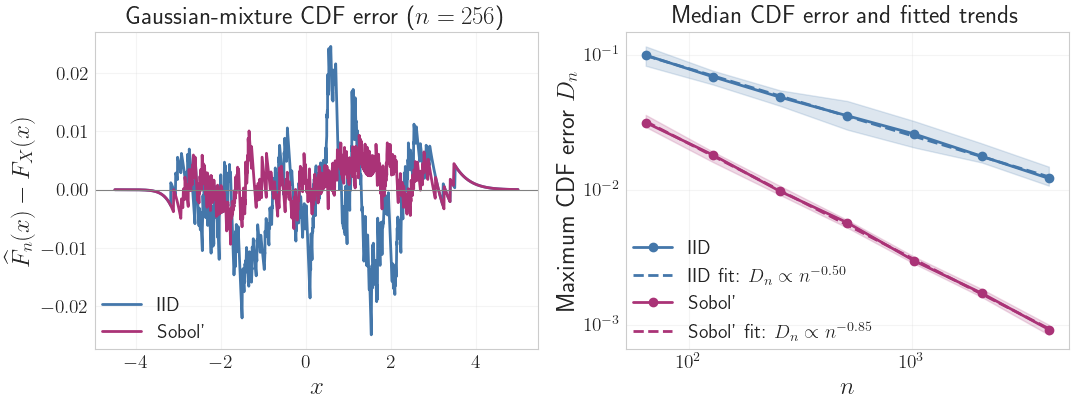

In [18]:
def mixture_transform(u):
    component = np.where(u[:, 0] <= mixture_p, 0, 1)
    return (mixture_mu[component]
            + mixture_sigma[component] * stats.norm.ppf(u[:, 1]))


def mixture_cdf(x):
    return (mixture_p * stats.norm.cdf(x, loc=mixture_mu[0], scale=mixture_sigma[0])
            + (1 - mixture_p)
            * stats.norm.cdf(x, loc=mixture_mu[1], scale=mixture_sigma[1]))


mixture_sizes = 2 ** np.arange(6, 13)
mixture_repetitions = 32
mixture_methods = {"IID": qp.IIDStdUniform, "Sobol'": qp.Sobol}
mixture_colors = {"IID": colors["blue"], "Sobol'": colors["purple"]}
mixture_errors = {}
mixture_trends = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

for label, sampler in mixture_methods.items():
    # A fresh unseeded sampler gives an independent replication/randomization.
    example = np.sort(mixture_transform(sampler(2)(256)))
    grid = np.sort(np.concatenate([mixture_grid, example]))
    empirical_cdf = np.searchsorted(example, grid, side="right") / example.size
    axes[0].plot(grid, empirical_cdf - mixture_cdf(grid),
                 color=mixture_colors[label], label=label)

    errors = np.empty((mixture_repetitions, len(mixture_sizes)))
    for rep in range(mixture_repetitions):
        # Nested prefixes within each replication; independent across replications.
        samples = mixture_transform(sampler(2)(int(mixture_sizes[-1])))
        for j, size in enumerate(mixture_sizes):
            target_cdf = mixture_cdf(np.sort(samples[:size]))
            ranks = np.arange(1, size + 1)
            errors[rep, j] = max(np.max(ranks / size - target_cdf),
                                 np.max(target_cdf - (ranks - 1) / size))
    mixture_errors[label] = errors
    lower, median, upper = np.quantile(errors, [0.25, 0.5, 0.75], axis=0)
    axes[1].loglog(mixture_sizes, median, "o-", color=mixture_colors[label], label=label)
    axes[1].fill_between(mixture_sizes, lower, upper,
                         color=mixture_colors[label], alpha=0.18)
    slope, log_amplitude = np.polyfit(np.log(mixture_sizes), np.log(median), 1)
    amplitude = np.exp(log_amplitude)
    mixture_trends[label] = (amplitude, slope)
    axes[1].loglog(mixture_sizes, amplitude * mixture_sizes ** slope, "--",
                   color=mixture_colors[label], lw=2,
                   label=rf"{label} fit: $D_n \propto n^{{{slope:.2f}}}$")

axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set(xlabel="$x$", ylabel=r"$\widehat F_n(x)-F_X(x)$",
            title="Gaussian-mixture CDF error ($n=256$)")
axes[1].set(xlabel="$n$", ylabel=r"Maximum CDF error $D_n$",
            title="Median CDF error and fitted trends")
for ax in axes:
    ax.legend(loc = 'lower left')
    ax.grid(alpha=0.2)
plt.tight_layout()

for label, (amplitude, slope) in mixture_trends.items():
    print(f"{label}: fitted median CDF error = {amplitude:.3g} n^({slope:.3f})")


### Asian Arithmetic Mean Call Option

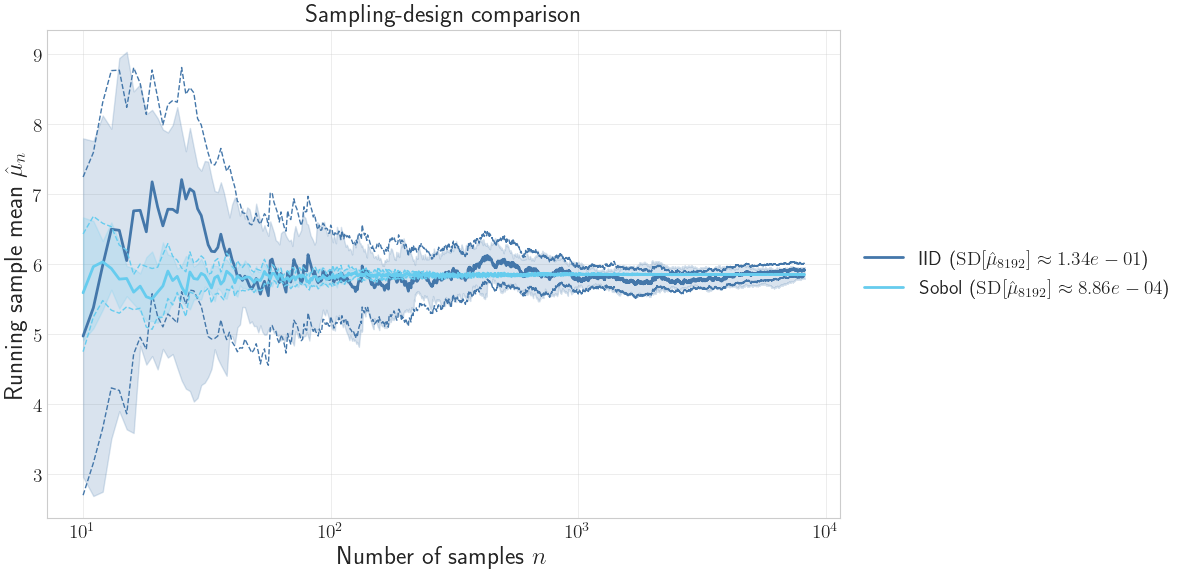

In [19]:
configs = {
    "IID": {
        "sampler": lambda n: np.random.random((n, n_steps)),
        "f": asian_option.f,
    },
    "Sobol": {
        "sampler": lambda n: qp.Sobol(n_steps).gen_samples(n),
        "f": asian_option.f,
    },
}

ax, info = cl.plots.plot_multiple_middle_half_sample_means(
    configs,
    n_max=2**13,
    n_rep=21,
    title="Sampling-design comparison",
)

<div class="highlight-note">
For this example, the randomized Sobol' estimates concentrate more tightly than the IID estimates.
</div>

In [20]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 5.6 sec.
